# Exploring Semantic Structure and Bias in Word Embeddings

## Introduction

Word embeddings represent words as dense numerical vectors that encode semantic meaning in high-dimensional space. Instead of treating words as isolated symbols, embedding models learn representations where similar words are positioned near each other geometrically.

This project explores how pretrained word embeddings:

- Capture semantic similarity through cosine similarity
- Encode analogical relationships using vector arithmetic
- Reflect social and cultural bias present in training data
- Differ across embedding models (Word2Vec, GloVe, fastText)

Understanding word embeddings is foundational for modern NLP systems. Transformer architectures, including models like GPT and BERT, begin with embedding layers before applying attention mechanisms. Studying static embeddings helps build intuition for how language models represent meaning mathematically.

## Background Theory

### The Distributional Hypothesis

Word embeddings are built on the *distributional hypothesis*, which states:

 "You shall know a word by the company it keeps."

Words that appear in similar contexts tend to have similar meanings. By analyzing large corpora of text, embedding models learn vector representations that capture these contextual relationships.

---

### Cosine Similarity

To measure similarity between two word vectors, we use cosine similarity:

\[
\text{cosine similarity}(A, B) = \frac{A \cdot B}{||A|| \, ||B||}
\]

This measures the angle between vectors rather than their magnitude. A value close to 1 indicates strong similarity, while values near 0 indicate weak similarity.

---

### Vector Arithmetic and Analogies

One of the most remarkable properties of embeddings is that semantic relationships become linear in vector space. For example:

\[
\text{king} - \text{man} + \text{woman} \approx \text{queen}
\]

This works because relationships such as gender or tense often form consistent directional patterns in the embedding space.

---

### Static vs Contextual Embeddings

The embeddings explored in this project (Word2Vec, GloVe, fastText) are *static*. Each word has exactly one vector regardless of context.

For example, the word "bank" has a single embedding whether it refers to:
- A financial institution
- The side of a river

Modern transformer models instead produce *contextual embeddings*, where the representation of a word depends on surrounding words. This solves many limitations of static embeddings.

## Methods Overview

This analysis uses pretrained embeddings loaded via the `gensim` library. 
Cosine similarity measures semantic closeness, vector arithmetic tests analogy 
structure, and projection onto a gender direction vector quantifies bias. 
Principal Component Analysis (PCA) is used to visualize high-dimensional 
embeddings in two dimensions.

In [22]:
!pip install gensim --quiet

import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [23]:
import os
os.makedirs("outputs", exist_ok=True)

In [24]:
print("Loading Word2Vec model...")
word2vec = api.load("word2vec-google-news-300")

print("Loading GloVe model...")
glove = api.load("glove-wiki-gigaword-100")

print("Loading fastText model...")
fasttext = api.load("fasttext-wiki-news-subwords-300")

print("Models loaded successfully!")

Loading Word2Vec model...
Loading GloVe model...
Loading fastText model...
Models loaded successfully!


## Semantic Similarity Exploration

To explore how embeddings encode meaning, I examined the most similar words to selected terms such as "king," "computer," and "doctor."

The results demonstrate that embeddings cluster words based on semantic and contextual similarity:

- "king" is close to monarch, queen, prince
- "computer" is close to laptop, PC, computers
- "doctor" is close to physician, surgeon, dentist

This confirms that embeddings capture meaningful semantic neighborhoods in vector space.

In [25]:
def show_similar(model, word):
    print(f"\nTop similar words to '{word}':")
    for w, score in model.most_similar(word, topn=10):
        print(f"{w:15s} {score:.3f}")

show_similar(word2vec, "king")
show_similar(word2vec, "computer")
show_similar(word2vec, "doctor")


Top similar words to 'king':
kings           0.714
queen           0.651
monarch         0.641
crown_prince    0.620
prince          0.616
sultan          0.586
ruler           0.580
princes         0.565
Prince_Paras    0.543
throne          0.542

Top similar words to 'computer':
computers       0.798
laptop          0.664
laptop_computer 0.655
Computer        0.647
com_puter       0.608
technician_Leonard_Luchko 0.566
mainframes_minicomputers 0.562
laptop_computers 0.559
PC              0.554
maker_Dell_DELL.O 0.552

Top similar words to 'doctor':
physician       0.781
doctors         0.748
gynecologist    0.695
surgeon         0.679
dentist         0.679
pediatrician    0.664
pharmacist      0.653
neurologist     0.652
cardiologist    0.635
nurse           0.632


## Analogy Experiments

I tested classical analogy tasks such as:

- man : king :: woman : ?
- paris : france :: germany : ?
- good : better :: bad : ?

The embedding model correctly predicts:

- queen
- europe (or england/spain depending on model)
- worse

These results show that embeddings encode relationships as consistent vector directions. This linear structure in high-dimensional space is one of the most powerful properties of word embeddings.

In [26]:
def analogy(model, a, b, c):
    result = model.most_similar(positive=[b, c], negative=[a], topn=1)[0][0]
    print(f"{a} : {b} :: {c} : {result}")

analogy(word2vec, "man", "king", "woman")
analogy(word2vec, "paris", "france", "germany")
analogy(word2vec, "walking", "walked", "swimming")
analogy(word2vec, "good", "better", "bad")

man : king :: woman : queen
paris : france :: germany : europe
walking : walked :: swimming : swam
good : better :: bad : worse


## Bias Analysis

To investigate gender bias, I constructed a gender direction vector:

\[
\text{gender vector} = \text{woman} - \text{man}
\]

I then projected profession vectors onto this direction using dot products.

Positive projection values indicate alignment toward the female direction, while negative values indicate alignment toward the male direction.

The results reveal systematic patterns:

- Nurse, receptionist, homemaker → stronger alignment with female direction
- Engineer, manager, programmer → stronger alignment with male direction

These associations reflect patterns in the training corpus rather than objective truth. Because embeddings are trained on large collections of real-world text, they inevitably absorb historical and societal biases.

This highlights a major limitation of static embeddings: they encode statistical regularities in language, including undesirable stereotypes.

Bias in embeddings is not random — it is learned from data.

## Gender Bias Analysis

engineer        -0.3311
manager         -0.3263
programmer      -0.1767
scientist       0.1657
pilot           0.1834
teacher         0.7919
doctor          0.8247
nurse           1.7636
receptionist    1.7858
homemaker       2.0761


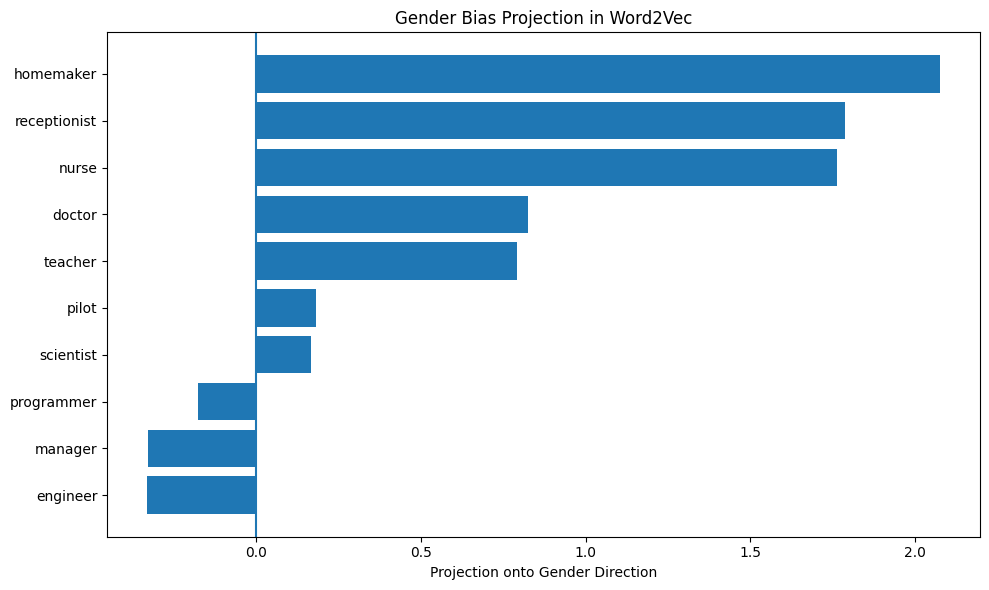

In [27]:
gender_vector = word2vec["woman"] - word2vec["man"]

professions = [
    "doctor","nurse","engineer","teacher","programmer",
    "homemaker","scientist","manager","pilot","receptionist"
]

def gender_bias_score(word):
    return np.dot(word2vec[word], gender_vector)

bias_scores = {p: gender_bias_score(p) for p in professions}

for p, score in sorted(bias_scores.items(), key=lambda x: x[1]):
    print(f"{p:15s} {score:.4f}")

sorted_bias = sorted(bias_scores.items(), key=lambda x: x[1])

labels = [x[0] for x in sorted_bias]
values = [x[1] for x in sorted_bias]

plt.figure(figsize=(10,6))
plt.barh(labels, values)
plt.axvline(0)
plt.title("Gender Bias Projection in Word2Vec")
plt.xlabel("Projection onto Gender Direction")
plt.tight_layout()

plt.savefig("outputs/gender_bias_projection.png", dpi=300)
plt.show()

The horizontal bar chart makes the directional separation clearer: 
professions such as nurse and receptionist align positively with the 
female direction, while engineer and manager align negatively. 
This visualization reinforces the numerical projection results.

## Model Comparison: Word2Vec vs GloVe vs fastText

I compared three embedding models:

- Word2Vec (Google News, 300d)
- GloVe (Wikipedia + Gigaword, 100d)
- fastText (Wikipedia + subword modeling, 300d)

All models capture semantic structure effectively, but differences emerge in analogy performance.

fastText often performs better on morphology-related tasks because it incorporates subword information. This allows it to better handle rare words and variations.

Word2Vec and GloVe rely on whole-word representations and cannot generate vectors for unseen words.

This comparison illustrates how architectural differences affect embedding behavior.

In [28]:
def compare_models(a,b,c):
    print("\nWord2Vec:", word2vec.most_similar(positive=[b,c], negative=[a], topn=1))
    print("GloVe   :", glove.most_similar(positive=[b,c], negative=[a], topn=1))
    print("fastText:", fasttext.most_similar(positive=[b,c], negative=[a], topn=1))

compare_models("man","king","woman")
compare_models("paris","france","italy")


Word2Vec: [('queen', 0.7118191719055176)]
GloVe   : [('queen', 0.7698541283607483)]
fastText: [('queen', 0.778674840927124)]

Word2Vec: [('england', 0.5573327541351318)]
GloVe   : [('spain', 0.7380696535110474)]
fastText: [('europe', 0.6396906971931458)]


In [29]:
analogy_tests = [
    ("man","king","woman"),
    ("paris","france","italy"),
    ("walking","walked","swimming"),
    ("good","better","bad")
]

results = []

for a,b,c in analogy_tests:
    w2v = word2vec.most_similar(positive=[b,c], negative=[a], topn=1)[0][0]
    glv = glove.most_similar(positive=[b,c], negative=[a], topn=1)[0][0]
    ft  = fasttext.most_similar(positive=[b,c], negative=[a], topn=1)[0][0]
    
    results.append([f"{a}:{b}::{c}", w2v, glv, ft])

import pandas as pd
df = pd.DataFrame(results, columns=["Analogy","Word2Vec","GloVe","fastText"])
df

,Analogy,Word2Vec,GloVe,fastText
0,man:king::woman,queen,queen,queen
1,paris:france::italy,england,spain,europe
2,walking:walked::swimming,swam,athletics,swam
3,good:better::bad,worse,worse,worse


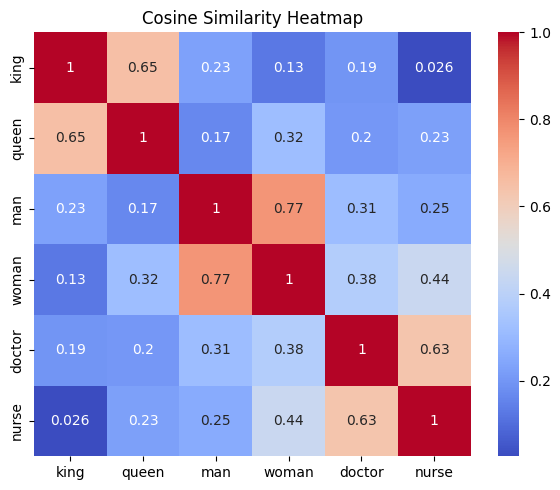

In [30]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

selected_words = ["king","queen","man","woman","doctor","nurse"]

vectors = np.array([word2vec[w] for w in selected_words])
sim_matrix = cosine_similarity(vectors)

plt.figure(figsize=(6,5))
sns.heatmap(sim_matrix, xticklabels=selected_words, yticklabels=selected_words, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Heatmap")
plt.tight_layout()
plt.savefig("outputs/similarity_heatmap.png", dpi=300)
plt.show()

## PCA Visualization of Embedding Space

Since embeddings exist in high-dimensional space (100–300 dimensions), I applied Principal Component Analysis (PCA) to reduce them to 2 dimensions for visualization.

The visualization reveals clustering patterns:

- Royal terms cluster together (king, queen, prince, princess)
- Gender-related words form groupings (man, woman, boy, girl)
- Countries cluster near their capitals (France/Paris, Germany/Berlin)
- Professions show partial grouping patterns

Although dimensionality reduction distorts some relationships, the visualization demonstrates that semantic organization exists geometrically in embedding space.

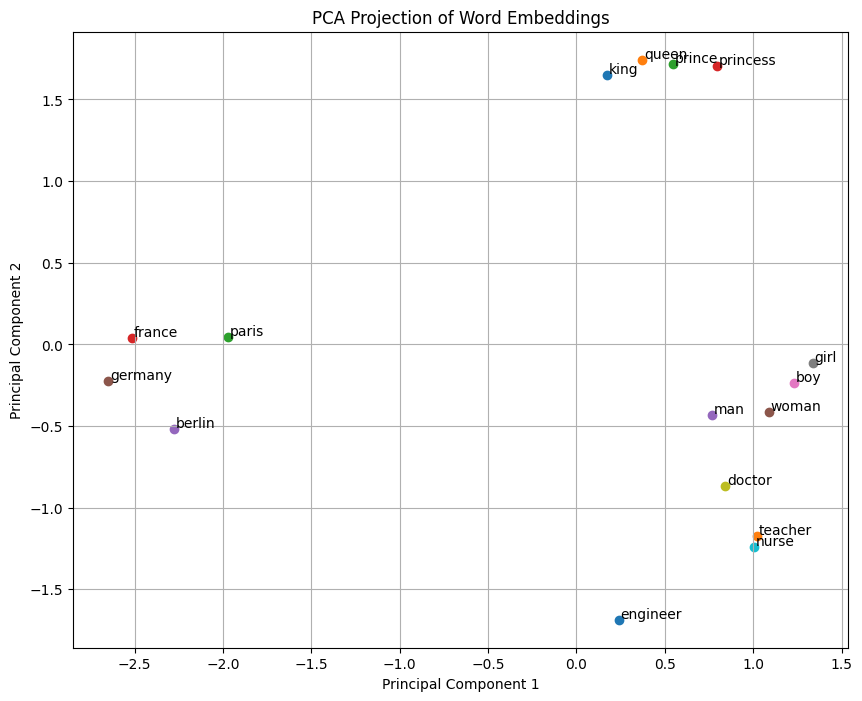

In [31]:
import os
os.makedirs("outputs", exist_ok=True)

words = [
    "king","queen","prince","princess",
    "man","woman","boy","girl",
    "doctor","nurse","engineer","teacher",
    "paris","france","berlin","germany"
]

vectors = np.array([word2vec[w] for w in words])

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(10,8))

for i, word in enumerate(words):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("PCA Projection of Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.savefig("outputs/pca_embedding_clusters.png", dpi=300)
plt.show()

The clustering visible in PCA space demonstrates that embeddings 
organize semantic relationships geometrically, even after reducing 
from 300 dimensions to 2.

## Limitations and Connection to Transformers

While static embeddings capture impressive semantic structure, they have important limitations:

1. Each word has only one representation regardless of context.
2. Polysemy (multiple meanings) is not handled well.
3. Bias present in training data is directly encoded.
4. They cannot dynamically adapt to new contexts.

Transformer models address these limitations by generating contextual embeddings. Through attention mechanisms, each word's representation depends on surrounding words.

For example, in a transformer model:
- "bank" in "river bank" will have a different embedding than "bank" in "open a bank account."

Thus, static embeddings like Word2Vec were foundational, but modern NLP systems rely on contextual embedding architectures.

## Conclusion

This project demonstrates that word embeddings encode meaning geometrically in vector space.

Through similarity tests, analogies, bias projections, and visualization, we observe that:

- Semantic relationships become linear directions
- Contextual similarity translates into geometric proximity
- Bias emerges naturally from corpus statistics
- Model architecture influences representation quality

Studying static embeddings provides intuition for how modern transformer models begin representing language mathematically before applying attention mechanisms.

Embeddings reveal that language can be modeled as structured linear algebra — a powerful and elegant foundation for large language models.